# **VAR using Parametric Approach**

The Parametric approach, also known as the Variance–Covariance method, is a widely used technique for estimating Value at Risk (VaR). Under this method, portfolio risk is quantified by estimating the volatility of returns, typically measured using the standard deviation derived from historical data or statistical models.

The approach assumes that portfolio returns follow a normal distribution, which allows VaR to be calculated analytically for a given confidence level. By combining the estimated volatility with the appropriate z-score, the method provides a closed-form estimate of the an estimate of the maximum expected loss over a specified time horizon under normal market conditions.

Kindly Note: In this implementation, the VaR estimate incorporates both portfolio volatility and expected returns over the holding period, rather than assuming zero mean returns.

In [1]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

years=15

end_date= dt.datetime.now()
start_date= end_date - dt.timedelta(days=365*years)

tickers= ['ICICIBANK.NS','HDFCBANK.NS','KOTAKBANK.NS','AXISBANK.NS','^NSEI']

In [ ]:
adj_close_df= pd.DataFrame()
for ticker in tickers:
  data= yf.download(ticker, start=start_date, end=end_date)
  adj_close_df[ticker]= data['Close']

log_returns= np.log(adj_close_df/adj_close_df.shift(1))
log_returns= log_returns.dropna()

In [3]:
portfolio_value= 1000000
weights= np.array([1/len(tickers)] * len(tickers))

historical_returns= (log_returns*weights).sum(axis=1)

In [4]:
days = 5
historical_x_day_returns = historical_returns.rolling(window=days).sum()

In [5]:
cov_matrix = log_returns.cov() * 252
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights)

In [6]:
confidence_levels = [0.95, 0.90, 0.99]

VaRs=[]
for cl in confidence_levels:
  VaR = -portfolio_value * (norm.ppf(1 - cl) * portfolio_std_dev * np.sqrt(days / 252) - historical_returns.mean() * days)
  VaRs.append(VaR)

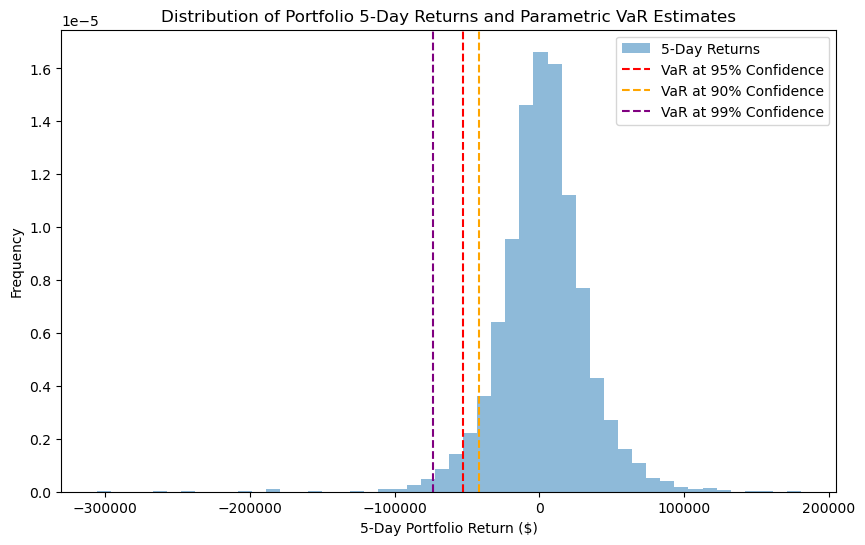

In [7]:
# Convert returns to dollar values for the histogram
historical_x_day_returns_dollar = historical_x_day_returns * portfolio_value

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(historical_x_day_returns_dollar, bins=50, density=True, alpha=0.5, label=f'{days}-Day Returns')

# Define colours for each confidence interval
color_map={0.90:'orange',0.95:'red',0.99:'purple'}

# Add vertical lines representing VaR at each confidence level
for cl, VaR in zip(confidence_levels, VaRs):
    plt.axvline(x=-VaR, linestyle='--', color=color_map.get(cl, 'black'), label='VaR at {}% Confidence'.format(int(cl * 100)))

plt.xlabel(f'{days}-Day Portfolio Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
plt.legend()
plt.show()